In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("highest_grossing_films.csv")

df.head()

,Rank,Peak,Title,Worldwide gross,Year
0,1,1,Avatar,"$2,923,710,708",2009
1,2,1,Avengers: Endgame,"$2,797,501,328",2019
2,3,3,Avatar: The Way of Water,"$2,334,484,620",2022
3,4,1,Titanic,"T$2,257,906,828",1997
4,5,5,Ne Zha 2,"NZ$2,215,690,000",2025


In [15]:
df["Worldwide gross"] = (
    df["Worldwide gross"]
    .astype(str)
    .str.replace(r"[^\d]", "", regex=True)
)

df["Worldwide gross"] = pd.to_numeric(df["Worldwide gross"])

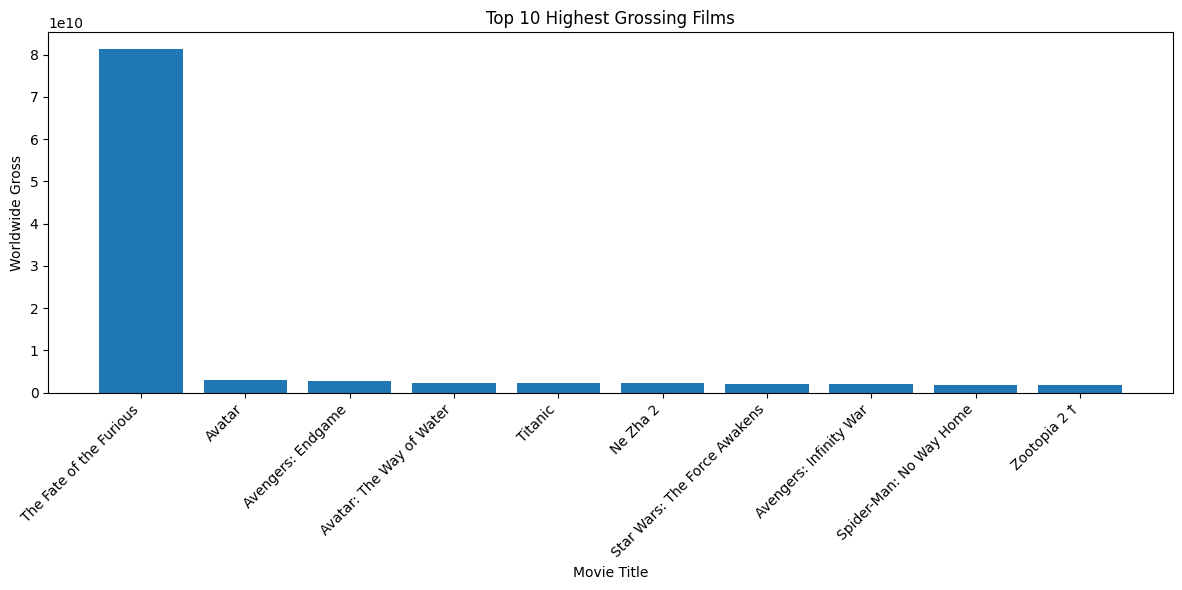

In [16]:
top10 = df.nlargest(10, "Worldwide gross")

plt.figure(figsize=(12,6))

plt.bar(top10["Title"], top10["Worldwide gross"])

plt.title("Top 10 Highest Grossing Films")
plt.xlabel("Movie Title")
plt.ylabel("Worldwide Gross")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

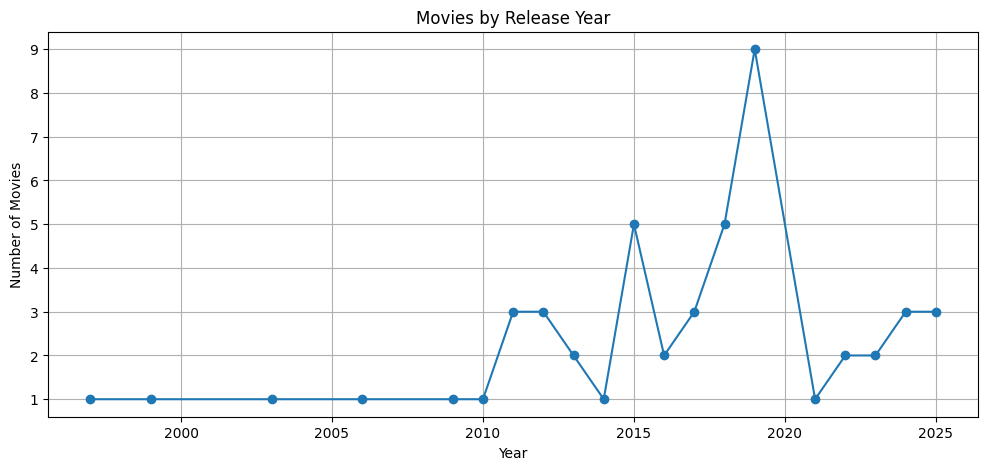

In [17]:
year_counts = df["Year"].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(year_counts.index, year_counts.values, marker="o")

plt.title("Movies by Release Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.grid(True)

plt.show()

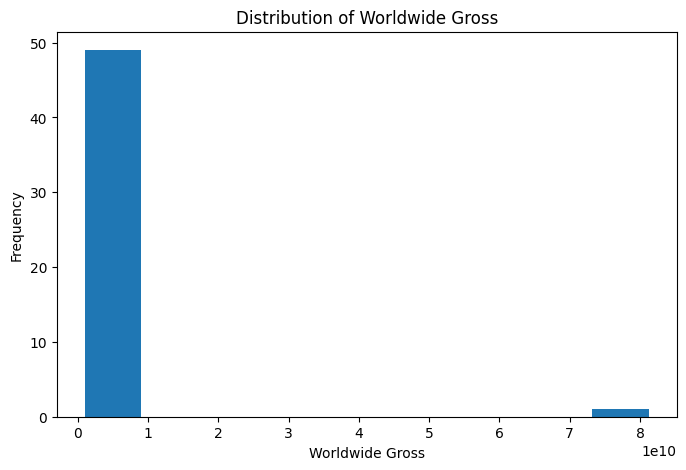

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["Worldwide gross"], bins=10)

plt.title("Distribution of Worldwide Gross")
plt.xlabel("Worldwide Gross")
plt.ylabel("Frequency")

plt.show()

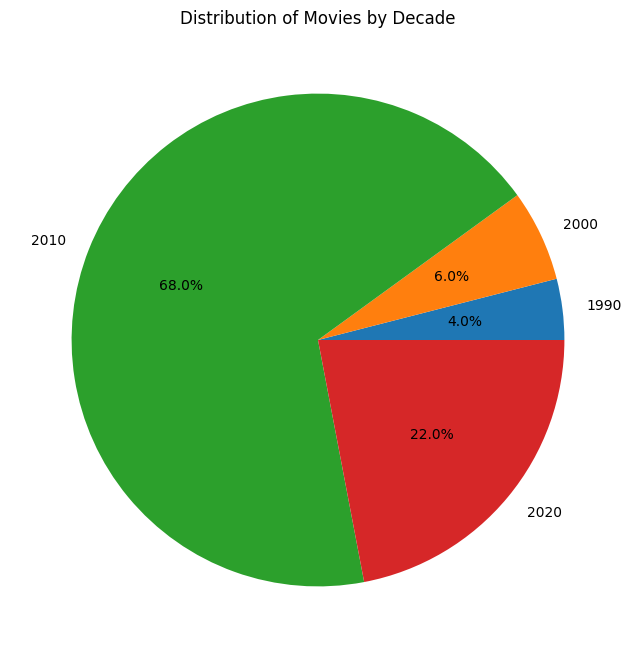

In [19]:
df["Decade"] = (df["Year"] // 10) * 10

decade_counts = df["Decade"].value_counts().sort_index()

plt.figure(figsize=(8,8))

plt.pie(
    decade_counts,
    labels=decade_counts.index,
    autopct="%1.1f%%"
)

plt.title("Distribution of Movies by Decade")

plt.show()